In [1]:
from urielplus.urielplus import URIELPlus
from calculators import SyntacticCalculator, MorphologicalCalculator, InventoryCalculator, PhonologicalCalculator, FeaturalCalculator
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
u = URIELPlus()
u.reset()
u.set_glottocodes()

Resetting to URIEL involves copying the files ['family_features.npz', 'features.npz', 'geocoord_features.npz'] into the data directory. Any files with the same name will be replaced. Continue? [Y/n] 

2026-03-04 13:40:33,323 - root - INFO - Converting ISO 639-3 codes to Glottocodes....
2026-03-04 13:40:33,396 - root - INFO - Conversion to Glottocodes complete.


In [6]:
df = pd.read_csv('toefl_scores_by_native_language.csv')

In [7]:
typ_file = 'typ.csv'
syn = SyntacticCalculator(typ_file)
morph = MorphologicalCalculator(typ_file)
inv = InventoryCalculator(typ_file)
phon = PhonologicalCalculator(typ_file)
feat = FeaturalCalculator(typ_file)

def distance(lang, typ):
    try:
        return u.new_distance(typ, 'stan1293', lang)
    except:
        return None
    
types = ['genetic', 'geographic']
for typ in types:
    df[typ] = df['code'].apply(lambda x: distance(x, typ))
    
df['syn'] = df['code'].apply(lambda x: syn.calculate_distance('stan1293', x))
df['morph'] = df['code'].apply(lambda x: morph.calculate_distance('stan1293', x))
df['inv'] = df['code'].apply(lambda x: inv.calculate_distance('stan1293', x))
df['phon'] = df['code'].apply(lambda x: phon.calculate_distance('stan1293', x))
types.extend(['syn', 'morph', 'inv', 'phon'])

2026-03-04 13:42:18,034 - root - INFO - In new_distance, calculated angular distance for genetic with stan1293 and afri1274: 0.1115720272064209 seconds
2026-03-04 13:42:18,146 - root - INFO - In new_distance, calculated angular distance for genetic with stan1293 and akan1250: 0.11097431182861328 seconds
2026-03-04 13:42:18,258 - root - INFO - In new_distance, calculated angular distance for genetic with stan1293 and alba1267: 0.11181068420410156 seconds
2026-03-04 13:42:18,370 - root - INFO - In new_distance, calculated angular distance for genetic with stan1293 and amha1245: 0.1107642650604248 seconds
2026-03-04 13:42:18,482 - root - INFO - In new_distance, calculated angular distance for genetic with stan1293 and stan1318: 0.11111807823181152 seconds
2026-03-04 13:42:18,593 - root - INFO - In new_distance, calculated angular distance for genetic with stan1293 and nucl1235: 0.11105585098266602 seconds
2026-03-04 13:42:18,705 - root - INFO - In new_distance, calculated angular distance

Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
Language nan not found in dataframe.
L

In [9]:
df = df.dropna(subset=types + ['Speaking', 'Writing', 'Listening', 'Reading'])
X = df[types]
Y = df[['Speaking', 'Writing', 'Listening', 'Reading']]

Speaking: best alpha = 88.0488
Writing: best alpha = 105.9560
Listening: best alpha = 66.6992
Reading: best alpha = 73.1681

Final alpha (mean across outcomes): 83.4680

Ridge Coefficients (standardized):
                    Speaking  Writing  Listening  Reading
genetic              -0.1197  -0.0975    -0.0868  -0.0851
geographic           -0.1301  -0.0846    -0.1579  -0.1208
syntactic            -0.0604  -0.0458    -0.0703  -0.0671
morphological        -0.0220  -0.0531    -0.0758  -0.0799
phonetic_inventory    0.0029   0.0282     0.0693   0.0651
phonological         -0.1268  -0.1410    -0.1274  -0.1245
Speaking R²: 0.2572
Writing R²: 0.2072
Listening R²: 0.3035
Reading R²: 0.2514


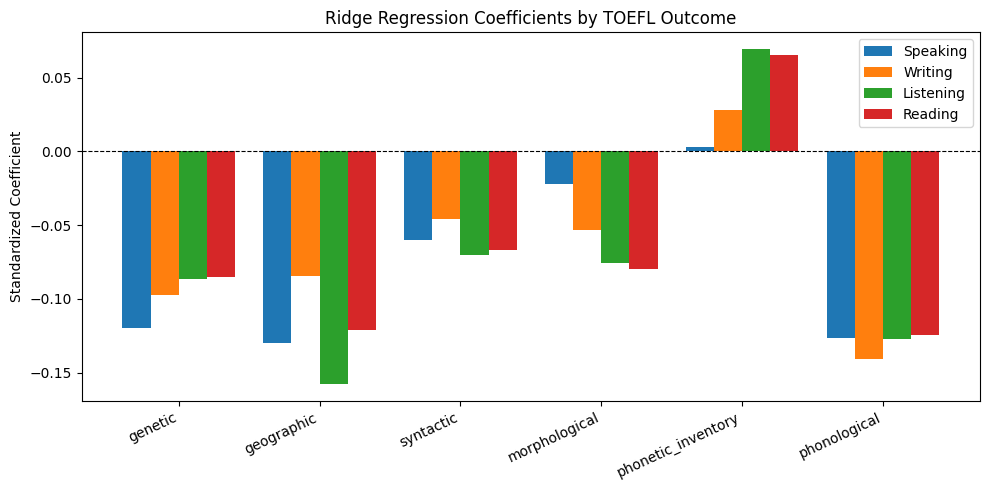

In [10]:
# ── 1. Scale features (critical for ridge) ────────────────────────────────────
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)  # shape: (n_samples, 6)
Y_scaled = scaler_Y.fit_transform(Y)  # shape: (n_samples, 4)

# ── 2. Find optimal alpha (lambda) via cross-validation ───────────────────────
# RidgeCV does this automatically; we search over a wide range
alphas = np.logspace(-3, 5, 200)

# For multivariate Y, we find the best alpha per outcome then pick one
best_alphas = []
for i, outcome in enumerate(['Speaking', 'Writing', 'Listening', 'Reading']):
    ridge_cv = RidgeCV(alphas=alphas, scoring='r2', cv=5)
    ridge_cv.fit(X_scaled, Y_scaled[:, i])
    best_alphas.append(ridge_cv.alpha_)
    print(f"{outcome}: best alpha = {ridge_cv.alpha_:.4f}")

# Use the mean alpha across outcomes (common practical choice)
final_alpha = np.mean(best_alphas)
print(f"\nFinal alpha (mean across outcomes): {final_alpha:.4f}")

# ── 3. Fit final model ─────────────────────────────────────────────────────────
ridge = Ridge(alpha=final_alpha)
ridge.fit(X_scaled, Y_scaled)

# ── 4. Inspect coefficients ───────────────────────────────────────────────────
feature_names = ['genetic', 'geographic', 'syntactic', 
                 'morphological', 'phonetic_inventory', 'phonological']
outcomes      = ['Speaking', 'Writing', 'Listening', 'Reading']

coef_df = pd.DataFrame(ridge.coef_.T, 
                        index=feature_names, 
                        columns=outcomes)
print("\nRidge Coefficients (standardized):")
print(coef_df.round(4))

# ── 5. Model performance ──────────────────────────────────────────────────────
from sklearn.metrics import r2_score

Y_pred = ridge.predict(X_scaled)
for i, outcome in enumerate(outcomes):
    r2 = r2_score(Y_scaled[:, i], Y_pred[:, i])
    print(f"{outcome} R²: {r2:.4f}")

# ── 6. Plot: coefficients across outcomes ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(feature_names))
width = 0.2

for i, outcome in enumerate(outcomes):
    ax.bar(x + i * width, coef_df[outcome], width=width, label=outcome)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(feature_names, rotation=25, ha='right')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel("Standardized Coefficient")
ax.set_title("Ridge Regression Coefficients by TOEFL Outcome")
ax.legend()
plt.tight_layout()
plt.show()